## ❖	Task 1 — Data Import & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re

%matplotlib inline

In [2]:
df=pd.read_csv("social_media_engagement_5000_end.csv")
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [3]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,04-03-2023,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527


In [4]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
count,5000.000000,4850.000000,5000.000000,4850.000000,4850.000000,4850.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.454021,548042.909000,10107.043711,1502.195670,1002.629485,4014.503200,50013.732800,393698.224800,0.964356
std,26090.370121,14.912381,260646.957267,5789.819252,869.537889,579.615158,2308.096459,28844.939104,230927.884535,5.318029
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5068.500000,760.000000,498.000000,2017.750000,24988.250000,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.000000,4034.500000,49934.500000,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,15115.000000,2256.000000,1501.000000,6020.250000,74662.250000,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,799533.000000,191.504348


In [5]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

In [7]:
df.dtypes

user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object

In [53]:
num_cols = ['likes', 'comments', 'shares']
df[num_cols] = df[num_cols].fillna(df[num_cols].median()).astype('int64')


cat_cols = ['gender', 'sentiment']
df[cat_cols] = df[cat_cols].astype('category')


In [9]:
df['posted_at']=pd.to_datetime(df['posted_at'])

C:\Users\Asus\AppData\Local\Temp\ipykernel_13820\1513165936.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['posted_at']=pd.to_datetime(df['posted_at'])


In [54]:
df.dtypes

user_id                      int64
age                        float64
gender                    category
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                        int64
comments                     int64
shares                       int64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                 category
hashtags                    object
engagement_rate            float64
posted_at           datetime64[ns]
dtype: object

In [16]:
likes_np = df['likes'].to_numpy()
engagement_np = df[['likes', 'comments', 'shares']].to_numpy()

In [17]:
likes_np

array([ 7011., 11750.,  4862., ..., 13487., 16894., 14830.], shape=(5000,))

In [18]:
engagement_np 

array([[ 7011.,   354.,  1157.],
       [11750.,  2606.,  1807.],
       [ 4862.,   344.,   955.],
       ...,
       [13487.,    nan,   167.],
       [16894.,  1289.,  1713.],
       [14830.,   503.,  1798.]], shape=(5000, 3))

In [35]:
np_data = df.to_numpy()



In [40]:
Average_Likes=likes_np.mean()
print(Average_Likes)
#print("Average Likes:", likes_np.mean())

10106.9824


In [45]:
total_like=likes_np.sum()
print('total like :',total_like)
maximum_likes=likes_np.max()
print('maximum_likes:',maximum_likes)
minimum_likes=likes_np.min()
print('minimum_likes:',minimum_likes)


total like : 50534912
maximum_likes: 19998
minimum_likes: 10


## ❖	Task 2 — Data Cleaning

In [47]:
df.isnull()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,posted_at
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [48]:
cols = ['user_id','age','post_id','likes','comments','shares','watch_time_sec','impression_count','follower_count'
,'engagement_rate']
df[cols] = df[cols].fillna(df[cols].median())
#df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [59]:
#col=['gender','sentiment']
cat_cols = df.select_dtypes(include=['object','category']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Nulls after fillna:", df.isnull().sum().sum())

Nulls after fillna: 0


In [60]:
df.isnull().sum()

user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
posted_at           0
dtype: int64

In [61]:
df.duplicated().sum()

np.int64(0)

In [65]:
# Convert date column
df['posted_at'] = pd.to_datetime(df['posted_at'], errors='coerce')

# Convert numerical columns
num_cols = ['likes', 'comments', 'shares', 'follower_count']
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

# Convert categorical columns
cat_cols = ['post_type']
df[cat_cols] = df[cat_cols].astype('category')

print(df.dtypes)

user_id                      int64
age                        float64
gender                    category
country                     object
post_id                      int64
post_type                 category
post_category               object
likes                        int64
comments                     int64
shares                       int64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                 category
hashtags                    object
engagement_rate            float64
posted_at           datetime64[ns]
dtype: object


In [66]:
df['post_type'] = df['post_type'].str.lower().str.strip()

In [67]:
# Set negatives to 0 or median
for col in num_cols:
    df[col] = df[col].clip(lower=0) # no negative values

    # Optional: cap extreme outliers at 99th percentile
    upper_limit = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper_limit)

print(df[num_cols].describe())

              likes     comments      shares  follower_count
count   5000.000000  5000.000000  5000.00000     5000.000000
mean   10106.287400  1501.899900  1002.83580   393662.193600
std     5701.098062   856.151215   570.72604   230865.271778
min       10.000000     0.000000     0.00000       87.000000
25%     5235.000000   792.000000   511.00000   194480.000000
50%    10105.000000  1497.000000  1012.00000   388982.000000
75%    14959.000000  2235.250000  1483.00000   589744.250000
max    19857.020000  2975.010000  1983.00000   792524.700000


In [72]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,posted_at
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157,5726,44650,2022-12-17,81734.0,False,mobile,negative,3,0.190862,2022-12-17
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807,5947,80216,2023-06-02,5963.0,False,mobile,negative,1,0.201493,2023-06-02
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955,6946,44858,2023-05-07,501783.0,False,tablet,positive,1,0.137345,2023-05-07
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049,229,70455,2023-02-12,480212.0,False,mobile,negative,3,0.106195,2023-02-12
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300,4798,6019,2023-05-23,383936.0,False,mobile,negative,1,2.777372,2023-05-23


In [76]:
if 'platform' in df.columns:
    df['platform'] = df['platform'].str.lower().str.strip()
    platform_map = {'ig':'instagram','insta':'instagram','tt':'tiktok','fb':'facebook','yt':'youtube'}
    df['platform'] = df['platform'].replace(platform_map)

if 'sentiment' in df.columns:
    df['sentiment'] = df['sentiment'].str.lower().str.strip()
    sent_map = {'pos':'positive','neg':'negative','neu':'neutral'}
    df['sentiment'] = df['sentiment'].replace(sent_map)

In [77]:
for col in ['likes','comments','shares']:
    if col in df.columns:
        df[col] = df[col].clip(lower=0)
        df[col] = df[col].clip(upper=df[col].quantile(0.99))


## ❖ TASK 3 — DATA EXPLORATION

In [78]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,posted_at
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157,5726,44650,2022-12-17,81734.0,False,mobile,negative,3,0.190862,2022-12-17
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807,5947,80216,2023-06-02,5963.0,False,mobile,negative,1,0.201493,2023-06-02
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955,6946,44858,2023-05-07,501783.0,False,tablet,positive,1,0.137345,2023-05-07
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049,229,70455,2023-02-12,480212.0,False,mobile,negative,3,0.106195,2023-02-12
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300,4798,6019,2023-05-23,383936.0,False,mobile,negative,1,2.777372,2023-05-23


In [79]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,posted_at
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837,6190,42977,2022-06-25,646147.0,False,mobile,positive,2,0.466761,2022-06-25
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583,7764,34196,2022-11-18,584603.0,False,desktop,negative,2,0.621155,2022-11-18
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1497.0,167,7466,23680,2023-04-06,483550.0,False,desktop,positive,2,0.679688,2023-04-06
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713,4991,89013,2022-05-16,183295.0,False,tablet,positive,3,0.223518,2022-05-16
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798,3743,14234,2023-03-04,585760.0,False,desktop,neutral,3,1.203527,2023-03-04


In [80]:
df.shape

(5000, 20)

In [81]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'posted_at  '],
      dtype='object')

In [82]:
df.dtypes

user_id                      int64
age                        float64
gender                    category
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                      float64
comments                   float64
shares                       int64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count             float64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                     int64
engagement_rate            float64
posted_at           datetime64[ns]
dtype: object

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   category      
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   float64       
 14  is_verified       5000 n

In [84]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,hashtags,engagement_rate,posted_at
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000
mean,54561.890800,38.440400,548042.909000,10106.287202,1501.899801,1002.83580,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393662.193600,1.998600,0.964356,2022-12-28 13:21:30.240000
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.00000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,1.000000,0.006363,2022-01-01 00:00:00
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.00000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,1.000000,0.145781,2022-07-03 18:00:00
50%,54374.500000,38.000000,548077.500000,10105.000000,1497.000000,1012.00000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,2.000000,0.253896,2022-12-27 00:00:00
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.00000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,3.000000,0.504794,2023-06-28 00:00:00
max,99963.000000,64.000000,999455.000000,19857.000200,2975.000100,1983.00000,7998.000000,99995.000000,2023-12-31 00:00:00,792524.700000,3.000000,191.504348,2023-12-31 00:00:00
std,26090.370121,14.687151,260646.957267,5701.097723,856.151044,570.72604,2308.096459,28844.939104,NaN,230865.271778,0.812853,5.318029,NaN


In [87]:
print(df['post_type'].value_counts())


post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64


In [88]:
print(df['post_category'].nunique(), "unique categories")


8 unique categories


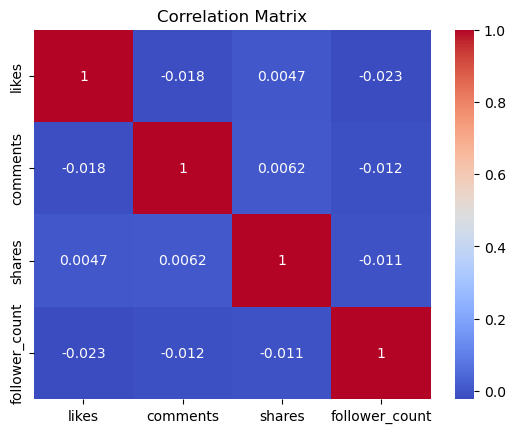

In [89]:
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [91]:
print(df.groupby('post_type')['likes'].mean().sort_values(ascending=False))
if 'country' in df.columns:
    print(df.groupby('country')['impression_count'].mean().sort_values(ascending=False).head())

post_type
video    10187.715104
image    10104.325583
text     10099.324500
reel     10037.203431
Name: likes, dtype: float64
country
India     52462.386916
France    51727.673387
USA       51263.872255
UK        51119.393509
Japan     49616.135593
Name: impression_count, dtype: float64


## ❖	Task 4 — Data Wrangling 

In [92]:
df['engagement_score'] = df['likes'] + df['comments']*2 + df['shares']*3
df['log_likes'] = np.log1p(df['likes'])

In [93]:
summary = df.groupby(['post_type','country','sentiment'])['engagement_score'].mean().reset_index()
print(summary.head())

  post_type    country sentiment  engagement_score
0     image  Australia  negative      13153.000000
1     image  Australia   neutral      16586.952386
2     image  Australia  positive      16589.984848
3     image     Brazil  negative      13887.800010
4     image     Brazil   neutral      14881.304348


## ❖	Task 5 — Statistical Analysis 

In [103]:
colums=['likes','comments','shares','watch_time_sec','engagement_rate']
print('mean:',df[colums].mean())
print('median:',df[colums].median())
print('mode:',df[colums].mode())
print("Std:", df[colums].std())
print("Var:", df[colums].var())
print("Percentiles 25/50/75:", df[col].quantile([0.25,0.5,0.75]).values)


mean: likes              10106.287202
comments            1501.899801
shares              1002.835800
watch_time_sec      4014.503200
engagement_rate        0.964356
dtype: float64
median: likes              10105.000000
comments            1497.000000
shares              1012.000000
watch_time_sec      4034.500000
engagement_rate        0.253896
dtype: float64
mode:         likes  comments  shares  watch_time_sec  engagement_rate
0     10105.0    1497.0  1012.0           916.0         0.006363
1         NaN       NaN     NaN          2145.0         0.007420
2         NaN       NaN     NaN          4360.0         0.012676
3         NaN       NaN     NaN          7003.0         0.012692
4         NaN       NaN     NaN          7688.0         0.015005
...       ...       ...     ...             ...              ...
4995      NaN       NaN     NaN             NaN        87.266094
4996      NaN       NaN     NaN             NaN        92.828829
4997      NaN       NaN     NaN             N

## ❖	Task 6 — Data Visualization (Min. 8 Plots Required)

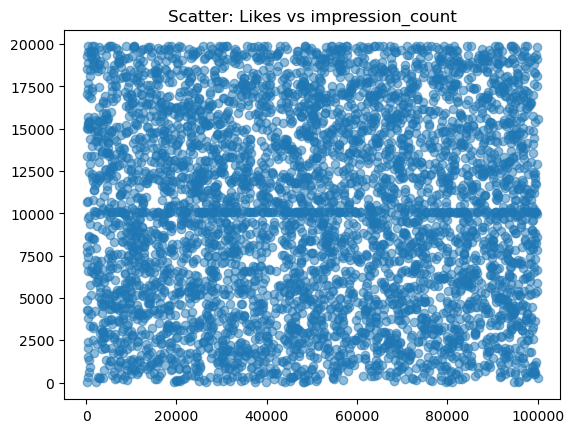

In [107]:
plt.scatter(df['impression_count'], df['likes'], alpha=0.5)
plt.title("Scatter: Likes vs impression_count"); plt.show()


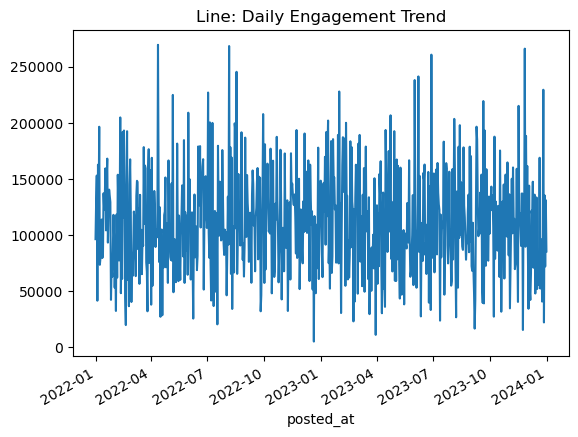

In [109]:
df.groupby('posted_at')['engagement_score'].sum().plot(kind='line')
plt.title("Line: Daily Engagement Trend"); plt.show()

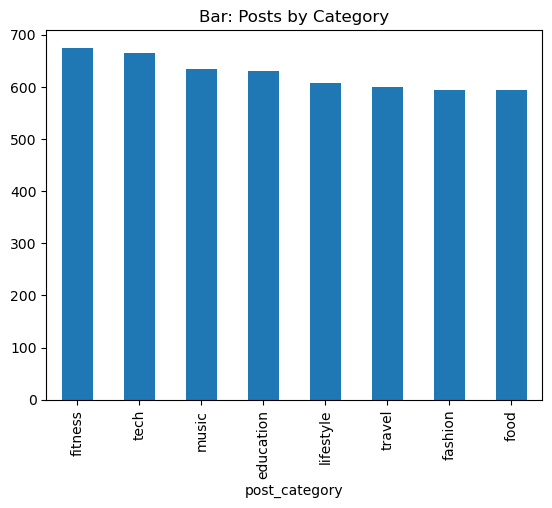

In [110]:
df['post_category'].value_counts().plot(kind='bar')
plt.title("Bar: Posts by Category"); plt.show()

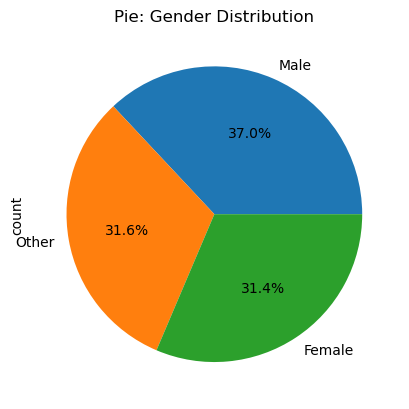

In [111]:
if 'gender' in df.columns:
    df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title("Pie: Gender Distribution"); plt.show()


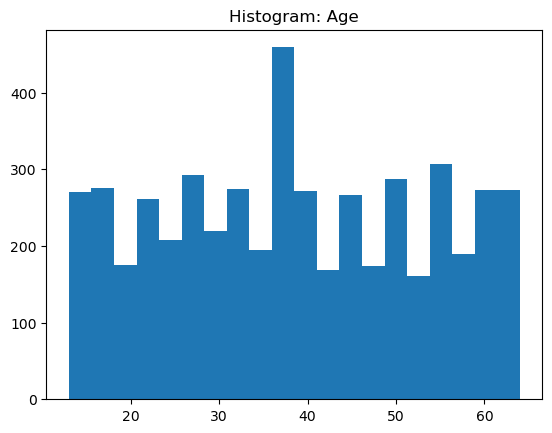

In [112]:
if 'age' in df.columns:
    plt.hist(df['age'], bins=20)
    plt.title("Histogram: Age"); plt.show()

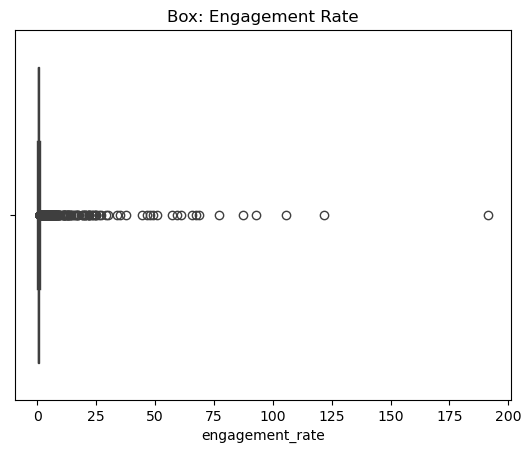

In [113]:
sns.boxplot(x=df['engagement_rate'])
plt.title("Box: Engagement Rate"); plt.show()

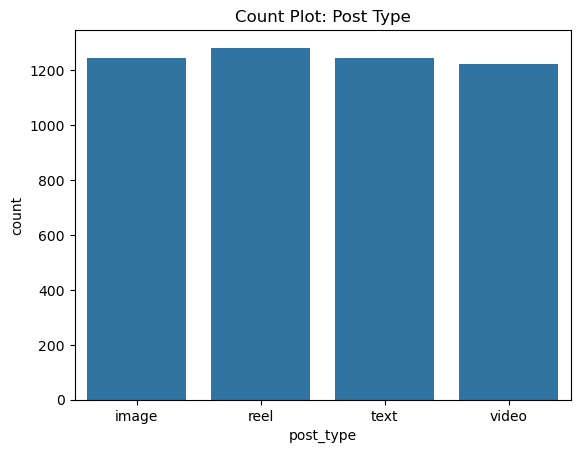

In [114]:
sns.countplot(x='post_type', data=df)
plt.title("Count Plot: Post Type"); plt.show()

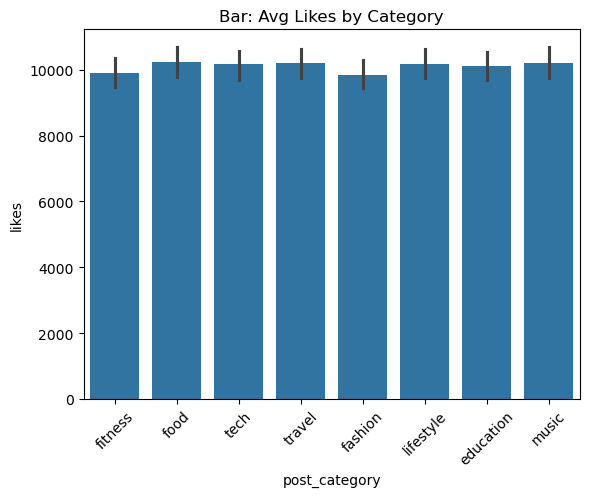

In [116]:
sns.barplot(x='post_category', y='likes', data=df, estimator=np.mean)
plt.xticks(rotation=45); plt.title("Bar: Avg Likes by Category"); plt.show()

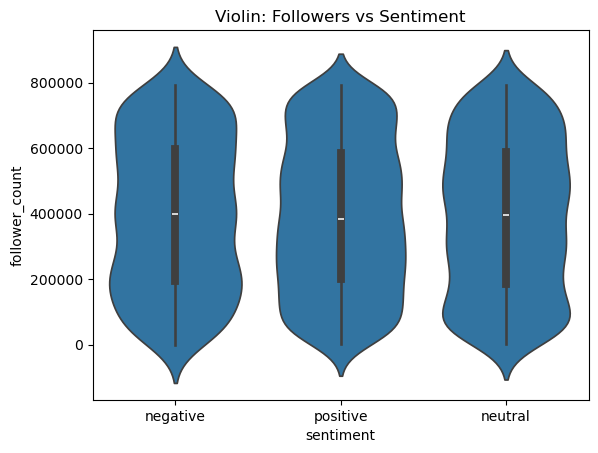

In [118]:
sns.violinplot(x='sentiment', y='follower_count', data=df)
plt.title("Violin: Followers vs Sentiment"); plt.show()


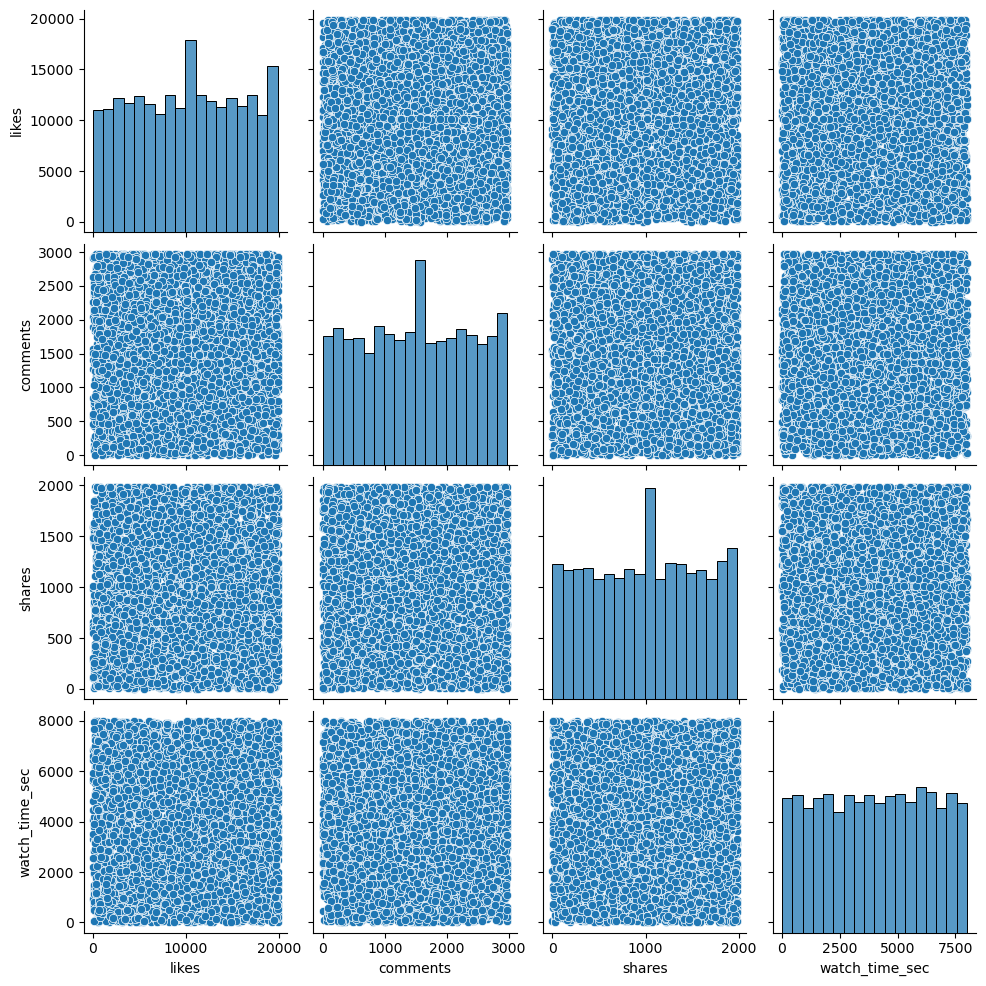

In [121]:

sns.pairplot(df[colums[:4]])
plt.show()

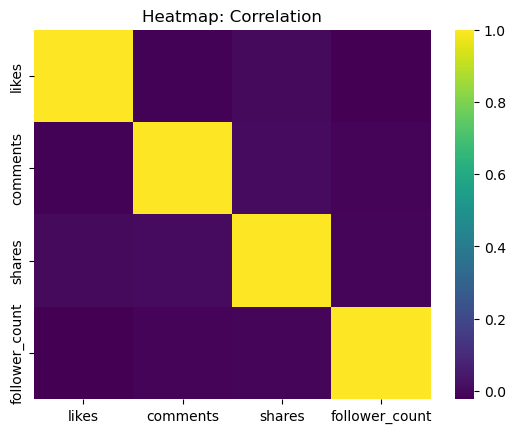

In [122]:
sns.heatmap(corr, cmap='viridis')
plt.title("Heatmap: Correlation"); plt.show()

In [ ]:
print('impression_count' in df.columns) 

fig = px.scatter(df, 
                 x='impression_count',  
                 y='likes', 
                 color='platform', 
                 size='shares',
                 title="Interactive: Likes vs Impressions",
                 hover_data=['post_type','category'])
fig.show()

In [ ]:
fig = px.scatter(df, x='impression_count', y='likes', color='platform', size='shares',title="Interactive: Likes vs Impressions")
fig.show()